# 26 — Atomic cells: rights profiles across three periods (LABEL-GROUNDED)

This notebook keeps the **original label-grounded** pipeline for comparison alongside the text-grounded re-analysis in **notebook 25**.

### What this version does

For each unique `(group, rule_polity)` pair (e.g. `Citizens` × `Classical Athens`), an LLM was asked to fill in the criterion vector using its background knowledge of Athenian / Greek / Roman legal practice. The resulting vector for `Citizens × Classical Athens` is `(male, adult, free, native, resident, any)` — even when individual verbatims under that label do not lexically constrain sex or age.

That is the move notebook 25 corrects (by reading each verbatim and marking each axis `stated` / `implied` / `unspecified`). Keep this notebook open *next* to 25 to read the two side by side.

| Pipeline | Unit | Source of criterion values | Output |
|---|---|---|---|
| **Notebook 25 (text-grounded)** | per rule | the verbatim itself + lexical presuppositions of emic words | `data/clean/final/rule_criterion_vectors.tsv` |
| **Notebook 26 (this one — label-grounded)** | per `(group, rule_polity)` | LLM's background knowledge of the polity's law | `data/clean/final/group_criterion_vectors.tsv` |

Three periods (identical to notebook 25):

| Code | Span | Rough scope |
|---|---|---|
| **P1** | Classical Greek (500–360 BCE) | Athenian democracy, Solonic, Cleisthenic |
| **P2** | Late Classical (354–165 BCE) | Demosthenes / Aristotle era, into Hellenistic |
| **P3** | Hellenistic & Roman (165 BCE – 205 CE) | Polybius onward — Greek polis under Rome |

## The six criteria and the values they can take

Each atomic cell is a tuple over six **rights-independent** criteria. Every criterion is a fact about persons that can be stated without referring to voting, court access, office-holding, or any other legal/rights category — so the same cell picks out the same humans even in a counterfactual society with different laws.

| Criterion | Values |
|---|---|
| `c_sex` | `Male` / `Female` / `*` |
| `c_age` | `Adult` / `Minor` / `Elder` / `*` |
| `c_ownership_status` | `Free` / `Enslaved` / `Freed` / `*` |
| `c_ancestry` | `Native` / `Foreign` / `Mixed` / `*` |
| `c_residence` | `Resident` / `Non resident` / `*` |
| `c_wealth` | `High` / `Middle` / `Low` / `*` |

**Reading a cell signature.** Cell codes are six tokens separated by `/`, in the fixed axis order **(sex, age, ownership, ancestry, residence, wealth)**. The token is the criterion value with the first letter capitalised. `*` means "unconstrained on this axis" (covering both "applies to all values" and "text doesn't say").

Examples:

- `Male/Adult/Free/Native/Resident/*` — the *politēs* / *civis* cell.
- `*/*/Enslaved/*/Resident/Low` — the *doulos* cell.
- `Female/Adult/Free/Native/Resident/*` — Athenian wives / *gynaikes* of citizen households.
- `Male/Adult/Free/Native/Resident/High` — the wealthy Solonic top class (*pentakosiomedimnoi*).

**Two metadata fields** travel alongside the criterion vector and are *not* part of the cell key:

- `requires_rights_definition` (`True` / `False`) — flagged when a group exists *only* as a legal/office category (`Magistrates`, `Voters`, `Archons`). These rows are filtered out below because their existence already presupposes the rights system.
- `emic_label` / `emic_label_in_text` — the native-language term (*politēs*, *metoikos*, *doulos*, *eupatridēs*, *pentakosiomedimnoi*, …). **A label observed on the cell, not its definition.**

The full prompt for each pipeline is in `scripts/classifiers/prompt/`.

In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
SRC = ROOT / 'data/clean/final/rules_with_criteria.tsv'
print('Loading from', SRC.relative_to(ROOT))

Loading from data/clean/final/rules_with_criteria.tsv


## 1. Load, periodize, and filter

Drop rules whose group is *intrinsically* a rights-defined category (`Magistrates`, `Voters`, …) and rules already flagged as tautological — the framework asks for the **non-circular** rights profile.

In [2]:
df = pd.read_csv(SRC, sep='\t')

AXES = ['c_sex','c_age','c_ownership_status','c_ancestry','c_residence','c_wealth']

# Human-readable cell signatures: "Male/Adult/Free/Native/Resident/*"
def _token(v):
    if pd.isna(v): return 'Unknown'
    v = str(v)
    if v in ('any','unspecified'): return '*'
    return v.replace('_', ' ').capitalize()

def cell_signature(row):
    return '/'.join(_token(row[c]) for c in AXES)

df['cell_sig'] = df.apply(cell_signature, axis=1)

PERIOD_MAP = {
    'Classical (500\u2013360 BCE)':                       'P1: Classical Greek (500\u2013360 BCE)',
    'Late Classical (354\u2013165 BCE)':                  'P2: Late Classical (354\u2013165 BCE)',
    'Hellenistic & Early Roman (165 BCE \u2013 105 CE)':  'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)',
    'High Roman Empire (135\u2013205 CE)':                'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)',
}
df['period3'] = df['period'].map(PERIOD_MAP)

mask = (df['requires_rights_definition'] != True) & (df['tautology'] != 1)
F = df[mask & df['period3'].notna()].copy()

PERIODS = ['P1: Classical Greek (500\u2013360 BCE)',
           'P2: Late Classical (354\u2013165 BCE)',
           'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)']

summary = (
    F.groupby('period3')
     .agg(n_rules=('rule_id','size'),
          n_cells=('cell_sig','nunique'),
          n_polities=('rule_polity','nunique'))
     .reindex(PERIODS)
)
summary

,n_rules,n_cells,n_polities
period3,,,
P1: Classical Greek (500–360 BCE),258,47,13
P2: Late Classical (354–165 BCE),365,53,36
P3: Hellenistic & Roman (165 BCE – 205 CE),215,65,45


## 2. The atomic cells

Each rule lives in exactly one cell. Signature is the 6-letter code over (sex, age, ownership, ancestry, residence, wealth).

In [3]:
AXES = ['c_sex','c_age','c_ownership_status','c_ancestry','c_residence','c_wealth']

def _join_unique(values, limit: int = 140) -> str:
    s = '; '.join(sorted({v for v in values if isinstance(v, str)}))
    return s if len(s) <= limit else s[:limit].rsplit('; ', 1)[0] + '; …'

def top_cells(period: str, k: int = 12) -> pd.DataFrame:
    s = F[F['period3'] == period]
    by = (
        s.groupby('cell_sig')
         .agg(n_rules=('rule_id','size'),
              groups=('group',        lambda x: _join_unique(x, 140)),
              emic_labels=('emic_label', lambda x: _join_unique(x, 110)))
         .reset_index()
         .sort_values('n_rules', ascending=False)
         .head(k)
    )
    return by[['cell_sig','n_rules','groups','emic_labels']]

for p in PERIODS:
    print('=' * 100)
    print(p)
    print('=' * 100)
    display(top_cells(p))

P1: Classical Greek (500–360 BCE)


,cell_sig,n_rules,groups,emic_labels
42,Male/Adult/Free/Native/Resident/*,89,Athenian citizens; Citizens; Citizens fit for military service; Orators and ...,athenaioi; homoios; idiōtēs; politēs; rhētores
19,*/Adult/Free/*/Resident/High,20,Property owners; The wealthy; Wealthy; Wealthy individuals,eupatridai; plousioi
5,*/*/Enslaved/*/Resident/Low,20,Slaves,douloi; doulos
26,Female/*/*/*/Resident/*,15,Women,gynaikes
43,Male/Adult/Free/Native/Resident/High,12,Noble men; Priests; Rich citizens; The elite; The powerful; Wealthy citizens,dynastai; eupatridai; hem-netjer; homoioi; kaloi kagathoi; plousioi
1,*/*/*/*/Resident/*,8,"Accidental killers; Homicide suspects; Musicians; Slaves, metics, and women;...",hiketēs; mousikoi
25,*/Minor/Free/Native/Resident/*,8,Minors,paides; pais
12,*/*/Free/Foreign/Resident/*,6,Metics; Resident aliens,metoikoi; metoikos
18,*/Adult/Free/*/Resident/*,5,Children who maltreat parents; Doctors; Philosophers; Priests,hem-netjer; iatroi; kakountes tous goneis; philosophos
10,*/*/Free/Foreign/*/*,5,Foreigners,xenos


P2: Late Classical (354–165 BCE)


,cell_sig,n_rules,groups,emic_labels
48,Male/Adult/Free/Native/Resident/*,102,Citizens; Comic poets; Men of Delphi; Men over thirty; Men who have prostitu...,Delphoi; agroikoi; eleutheroi; m' rtm; peporneumenoi; poiētēs; politai; poli...
22,*/Adult/Free/*/Resident/High,31,Owners of estates; The rich; The wealthy,euporoi; geōmoroi; plousioi
10,*/*/Free/*/Resident/Low,24,The poor,apori; penētes; thētes
5,*/*/Enslaved/*/Resident/Low,23,Slaves,douloi; doulos
49,Male/Adult/Free/Native/Resident/High,23,Citizens; Eupatridae; Influential citizens; Nobility; Nobles; Notables; Pent...,eupatridai; gnorimoi; gnōrimoi; homoioi; homoios; pentakosiomedimnoi; plousioi
32,*/Minor/Free/Native/Resident/*,14,Children of those who died in war; Minors; Orphans,orphanoi; paides; pais
34,Female/*/*/*/Resident/*,12,Women,gynaikes
15,*/*/Free/Native/Resident/*,9,Athenians; Athenians of 'polluted' lineage,Athēnaioi; enageis
50,Male/Adult/Free/Native/Resident/Low,9,Disabled paupers; The common people; The infirm poor; The multitude (freemen...,adunatoi; adynatoi; damos; hypomeiones; plēthos; thēs; thētes
12,*/*/Free/Foreign/Resident/*,9,Aliens; Free non-citizens; Metics; Resident aliens,metoikoi; metoikos; xenoi


P3: Hellenistic & Roman (165 BCE – 205 CE)


,cell_sig,n_rules,groups,emic_labels
60,Male/Adult/Free/Native/Resident/*,29,Achaean citizens; Citizens; Citizens of Greek city-states; Levites; Male cit...,Achaioi; Kohen; Lewi; Spartiatai; anēr; ephēbos; filii familias; politai; po...
18,*/*/Free/Native/Resident/*,10,Ancient family members; Argive subjects under tyranny; Athenians; Descendant...,Argeioi; Athēnaioi; Mantineis; Spartiatai; ebigoni; patricii
61,Male/Adult/Free/Native/Resident/High,9,Citizens; High-born men; Nobles; Prominent citizens; Wealthy citizens,eugeneis; gnorimoi; homoioi; homoios; plousioi
16,*/*/Free/Foreign/Resident/*,9,Foreigners; Resident aliens,peregrini; xenoi; xenos
8,*/*/Enslaved/*/Resident/Low,9,Slaves,doulos; servi; servus
41,Female/*/Free/Native/Resident/*,7,Daughters of public benefactors; Women,Lakaiai; gynaikes
52,Male/Adult/Free/*/Resident/*,6,Free men; Galli; Servants of Cronus; Soldiers; Teachers,Galli; eleutheroi; grammaticus; stratiōtai
19,*/*/Free/Native/Resident/High,6,Aristocrats; Nobility; Nobles; Patricians; The nobility,aristoi; eupatridai; nobilitas; patricii
38,Female/*/*/*/*/*,6,Women,gynaika; gynaikes
26,*/Adult/Free/*/*/High,6,The rich; The wealthy,locupletes; plousioi


## 3. The atomic-cell rights profile $\rho(G)$ per period — MORE only

We keep only the rules originally marked **MORE** (the rule says: this cell *holds* the right). LESS rules — *Slaves cannot testify*, *Women cannot vote* — are dropped from the analysis below. They cannot be safely flipped to a single positive cell in the general case (see the methodological note on markedness in earlier drafts), and for the partial-order story we want only direct positive evidence.

For each `(period, cell, resource)`, we report the count of MORE rules. The partial order in §4 will be built on this MORE-only dataset, `F_more`.

The `groups` column collects the English emic group labels whose rules landed at the cell — those are the inputs to the LLM that produced the criterion vector.

In [4]:
# F_more — only originally MORE rules. We drop LESS rules entirely for now
# (no markedness flip, no negative-evidence handling). The partial order can
# only be read as a *positive* rights map: cell A is above cell B iff A holds
# every right that B holds.
F_more = F[F['directionality'] == 'MORE'].copy()

def rho(period: str) -> pd.DataFrame:
    s = F_more[F_more['period3'] == period]
    by = (
        s.groupby(['cell_sig','resource_meta'])
         .size().reset_index(name='n_rules')
    )
    return by.sort_values(['cell_sig','n_rules'], ascending=[True, False])

rho_by_period = {p: rho(p) for p in PERIODS}
for p in PERIODS:
    r = rho_by_period[p]
    print(p, '→', r['cell_sig'].nunique(), 'cells,', r['resource_meta'].nunique(),
          'resources,', len(r), '(cell,resource) rows  [MORE rules only]')

P1: Classical Greek (500–360 BCE) → 39 cells, 29 resources, 95 (cell,resource) rows  [MORE rules only]
P2: Late Classical (354–165 BCE) → 36 cells, 35 resources, 111 (cell,resource) rows  [MORE rules only]
P3: Hellenistic & Roman (165 BCE – 205 CE) → 49 cells, 31 resources, 92 (cell,resource) rows  [MORE rules only]


In [5]:
def _join_unique(values, limit: int = 140) -> str:
    s = '; '.join(sorted({v for v in values if isinstance(v, str)}))
    return s if len(s) <= limit else s[:limit].rsplit('; ', 1)[0] + '; \u2026'

def groups_per_cell(period: str) -> pd.Series:
    s = F_more[F_more['period3'] == period]
    return s.groupby('cell_sig')['group'].agg(lambda x: _join_unique(x, 120))

for p in PERIODS:
    r = rho_by_period[p]
    g = groups_per_cell(p)
    r2 = (r.assign(groups=r['cell_sig'].map(g))
            .sort_values('n_rules', ascending=False)
            .head(15))
    print('\n' + '=' * 100)
    print(p)
    print('=' * 100)
    display(r2[['cell_sig','groups','resource_meta','n_rules']])


P1: Classical Greek (500–360 BCE)


,cell_sig,groups,resource_meta,n_rules
78,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Right to a legal trial,20
70,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Eligibility for public office,8
76,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Protection from legal prosecution,6
72,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Political power,5
82,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Right to citizenship,4
90,Male/Adult/Free/Native/Resident/High,Noble men; Priests; The elite; The powerful; Wealthy citizens,Eligibility for public office,4
41,Female/*/*/*/Resident/*,Women,Right to a dowry,4
89,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Right to vote in the Ekklesia,3
86,Male/Adult/Free/Native/Resident/*,Athenian citizens; Citizens; Orators and lawyers; Private citizens,Right to remuneration for office,3
52,Male/*/Free/*/Resident/*,Adopted sons,Right to inherit property,3



P2: Late Classical (354–165 BCE)


,cell_sig,groups,resource_meta,n_rules
81,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Eligibility for public office,13
84,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Political power,9
104,Male/Adult/Free/Native/Resident/High,Citizens; Eupatridae; Nobility; Nobles; Pentacosiomedimni; The distinguished...,Eligibility for public office,8
101,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Right to vote in the Ekklesia,8
89,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Right to a legal trial,8
98,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Right to remuneration for office,7
90,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Right to address the assembly,6
43,*/Adult/Free/*/Resident/High,Owners of estates; The rich; The wealthy,Eligibility for public office,4
12,*/*/Free/*/Resident/Low,The poor,Eligibility for public office,3
91,Male/Adult/Free/Native/Resident/*,Citizens; Comic poets; Men over thirty; Orators; Rural citizens,Right to bear arms,3



P3: Hellenistic & Roman (165 BCE – 205 CE)


,cell_sig,groups,resource_meta,n_rules
77,Male/Adult/Free/Native/Resident/*,Citizens; Citizens of Greek city-states; Levites; Male citizens; Married sons,Eligibility for public office,5
21,*/*/Free/Foreign/Resident/*,Foreigners; Resident aliens,Right to citizenship,4
78,Male/Adult/Free/Native/Resident/*,Citizens; Citizens of Greek city-states; Levites; Male citizens; Married sons,Political power,3
81,Male/Adult/Free/Native/Resident/*,Citizens; Citizens of Greek city-states; Levites; Male citizens; Married sons,Right to a legal trial,3
85,Male/Adult/Free/Native/Resident/*,Citizens; Citizens of Greek city-states; Levites; Male citizens; Married sons,Right to vote in the Ekklesia,3
53,Female/*/Free/Native/Resident/*,Daughters of public benefactors; Women,Political power,3
58,Male/*/Free/Native/Resident/High,Agiads and Eurypontids; Eurypontidae,Eligibility for public office,3
28,*/*/Free/Native/Resident/High,Aristocrats; Nobles; Patricians,Eligibility for public office,2
76,Male/Adult/Free/Native/Resident/*,Citizens; Citizens of Greek city-states; Levites; Male citizens; Married sons,Access to the gymnasium,2
24,*/*/Free/Native/Resident/*,Ancient family members; Athenians; Descendants of state benefactors; Patricians,Eligibility for public office,2


## 3b. Markedness symmetry — converting LESS rules into MORE rules on the complement

A LESS rule (e.g. *Slaves cannot vote*) is *negative* evidence at the cell of *slaves*. For the partial-order analysis in §4 we need *positive* rights at concrete cells. The **markedness move** rewrites some LESS rules as MORE rules on the *complementary* cell — but only when the complement is unambiguous.

### When the flip is valid

The flip is valid iff the LESS rule's category is a **binary opposition**: the negation of the marked value picks out a single complementary cell. We allow the flip on the five **binary axes**:

| Axis | Binary pair | Flip rule |
|---|---|---|
| `c_sex` | Male ↔ Female | LESS on Female ⇒ MORE on Male, and vice versa |
| `c_age` | Adult ↔ Minor | LESS on Minor ⇒ MORE on Adult, and vice versa |
| `c_ownership_status` | Free ↔ Enslaved | LESS on Enslaved ⇒ MORE on Free, and vice versa |
| `c_ancestry` | Native ↔ Foreign | LESS on Foreign ⇒ MORE on Native, and vice versa |
| `c_residence` | Resident ↔ Non-resident | LESS on Non-resident ⇒ MORE on Resident, and vice versa |

The flip is **not** allowed on `c_wealth` because it has three values (`High` / `Middle` / `Low`) — the negation of *Wealthy* is not a single complementary cell.

### Identifying the salient axis of a LESS rule

To know *which axis* to flip, we use a fixed group-label → axis mapping. For each LESS rule we look up the rule's `group` field and pick the salient axis:

| Group label keyword | Salient axis |
|---|---|
| Women, Wives, Daughters, Mothers, Female citizens, Female slaves | `c_sex` |
| Men, Husbands, Sons, Fathers, Male citizens | `c_sex` |
| Slaves, Slave | `c_ownership_status` |
| Free men, Free persons, Freedmen | `c_ownership_status` |
| Minors, Children, Adults, Elders, Orphans | `c_age` |
| Foreigners, Aliens, Metics, Resident aliens, Free non-citizens | `c_ancestry` |
| Natives | `c_ancestry` |
| Non-residents, Residents | `c_residence` |

If the rule's `group` is not in this mapping, we fall back to: **"exactly one of the five binary axes is pinned in the rule's cell"**. If that fails, the LESS rule is **dropped** — its negation is multi-axis (e.g. *Citizens cannot vote* pins five axes; *non-citizen* is a disjunction of many cells, not a single cell).

### What ends up in the analysis

We construct two datasets:

- **`F_more`** — only the original MORE rules (§3 uses this).
- **`F_pos`** — `F_more` ∪ flipped-LESS rules. Each flipped row has the directionality set to `MORE` and a new column `flipped_from_LESS_on_axis` recording which axis was flipped (`None` for the originally-MORE rows). The lifting analysis in §4 reads from `F_pos`.

The audit of how many rules were flipped vs dropped is printed below.

In [6]:
AXIS_FLIPS = {
    'c_sex':              {'male': 'female', 'female': 'male'},
    'c_age':              {'adult': 'minor', 'minor': 'adult'},
    'c_ownership_status': {'free': 'enslaved', 'enslaved': 'free'},
    'c_ancestry':         {'native': 'foreign', 'foreign': 'native'},
    'c_residence':        {'resident': 'non_resident', 'non_resident': 'resident'},
}

GROUP_TO_AXIS = {
    # sex axis
    'Women': 'c_sex', 'Wives': 'c_sex', 'Daughters': 'c_sex', 'Mothers': 'c_sex',
    'Female citizens': 'c_sex', 'Female slaves': 'c_sex',
    'Men': 'c_sex', 'Husbands': 'c_sex', 'Sons': 'c_sex', 'Fathers': 'c_sex',
    'Male citizens': 'c_sex',
    # ownership axis
    'Slaves': 'c_ownership_status', 'Slave': 'c_ownership_status',
    'Free men': 'c_ownership_status', 'Free persons': 'c_ownership_status',
    'Freedmen': 'c_ownership_status',
    # age axis
    'Minors': 'c_age', 'Children': 'c_age', 'Adults': 'c_age', 'Elders': 'c_age',
    'Orphans': 'c_age',
    # ancestry axis
    'Foreigners': 'c_ancestry', 'Aliens': 'c_ancestry', 'Metics': 'c_ancestry',
    'Resident aliens': 'c_ancestry', 'Natives': 'c_ancestry',
    'Free non-citizens': 'c_ancestry',
    # residence axis
    'Non-residents': 'c_residence', 'Residents': 'c_residence',
}

def primary_axis_for(group: str, row) -> str | None:
    if isinstance(group, str) and group in GROUP_TO_AXIS:
        ax = GROUP_TO_AXIS[group]
        if row[ax] in AXIS_FLIPS[ax]:
            return ax
    constrained = [a for a in AXIS_FLIPS if row[a] in AXIS_FLIPS[a]]
    return constrained[0] if len(constrained) == 1 else None

def try_flip(row):
    if row['directionality'] != 'LESS':
        return row.copy(), None
    axis = primary_axis_for(row.get('group',''), row)
    if axis is None:
        return None, None
    new_row = row.copy()
    new_row[axis] = AXIS_FLIPS[axis][row[axis]]
    new_row['directionality'] = 'MORE'
    new_row['flipped_from_LESS_on_axis'] = axis
    return new_row, axis

records = []
flipped, dropped = 0, 0
flipped_by_axis = {}
for _, row in F.iterrows():
    if row['directionality'] == 'LESS':
        new_row, axis = try_flip(row)
        if new_row is None:
            dropped += 1
            continue
        flipped += 1
        flipped_by_axis[axis] = flipped_by_axis.get(axis, 0) + 1
        records.append(new_row)
    else:
        rec = row.copy()
        rec['flipped_from_LESS_on_axis'] = None
        records.append(rec)

F_pos = pd.DataFrame(records).reset_index(drop=True)
F_pos['cell_sig'] = F_pos.apply(cell_signature, axis=1)

n_more_orig = int((F['directionality'] == 'MORE').sum())
n_less_orig = int((F['directionality'] == 'LESS').sum())
print(f'Original F:    {len(F):>4d} rules   ({n_more_orig} MORE, {n_less_orig} LESS)')
print(f'After flip:    {len(F_pos):>4d} rules  (all MORE in F_pos)')
print(f'   LESS flipped to MORE: {flipped} rules')
for ax, n in sorted(flipped_by_axis.items(), key=lambda x: -x[1]):
    print(f'       on {ax}: {n}')
print(f'   Unflippable LESS dropped: {dropped} rules')

Original F:     838 rules   (465 MORE, 373 LESS)
After flip:     612 rules  (all MORE in F_pos)
   LESS flipped to MORE: 147 rules
       on c_ancestry: 45
       on c_ownership_status: 42
       on c_sex: 39
       on c_age: 16
       on c_residence: 5
   Unflippable LESS dropped: 226 rules


## 4. The 64-cell lifted hierarchy — empirical social ranking on the network

We enumerate **every binary atomic cell** ($2^6 = 64$ fully-specified groups), lift rights for each from $F_{\text{pos}}$ (the markedness-flipped dataset from §3b), and now place each cell on a single network whose Y-position is the **empirical privilege score**.

### Stable, period-independent G-labels

Cells are numbered $G_1, G_2, \dots, G_{64}$ once and for all using a **privilege bit-pattern**: for each axis the privileged value (Male / Adult / Free / Native / Resident / High) is encoded as `0`, the non-privileged value as `1`. We read the 6 bits as a binary integer and sort ascending:

- **G1** = `Male/Adult/Free/Native/Resident/High` (canonically the most-privileged combination)
- ...
- **G64** = `Female/Minor/Enslaved/Foreign/Non-resident/Low` (canonically the most-dispossessed)

These G-labels are stable across the three periods.

### Empirical privilege score (drives the Y-axis of every diagram)

For each period $p$ and cell $A$ with axis values $(v_1, \dots, v_6)$:

$$\text{score}_p(A) \;=\; \sum_{k=1}^{6} \bar{r}_p\!\left(\text{axis}_k = v_k\right)$$

where $\bar{r}_p(\text{axis} = v)$ is the mean lifted-rights count over the 32 atomic cells carrying value $v$ on that axis in period $p$.

So if **being enslaved** systematically gives a cell fewer rights, the ownership-axis contribution to *every* Enslaved cell's score is low — and those cells fall to the bottom of the network. The hierarchy emerges naturally from how each axis-value performs empirically.

### Reading each Hasse diagram

- **One figure per period.**
- **Y-axis = empirical privilege score.** Top = most privileged; bottom = least privileged. The Y-tick labels are the actual score numbers.
- **Arrows.** $A \to B$ means $\rho(A) \supseteq \rho(B)$ strictly (rights inclusion), covering relations only. Some arrows may run sideways/upward because *score* and *rights count* are correlated but not identical — a cell can have a higher score than another without strictly containing its rights.
- **Node fill colour** = privilege score (red→green; greener = higher score). Position and colour agree, so the ranking is doubly visible.
- **Border style — provenance:**
  - *Solid dark* — the atomic cell is **observed** in $F_{\text{pos}}$ for this period.
  - *Dashed light* — **inferred** via lifting only.
- **Inside each node** sits the stable $G_i$ label. The unique English descriptive phrase sits below.
- The diagram shows the top 14 cells per period by score; the full 64-row legend table follows.

In [7]:
import networkx as nx
import itertools
import numpy as np

AXIS_VALS = {
    'c_sex':              ['Male', 'Female'],
    'c_age':              ['Adult', 'Minor'],
    'c_ownership_status': ['Free', 'Enslaved'],
    'c_ancestry':         ['Native', 'Foreign'],
    'c_residence':        ['Resident', 'Non resident'],
    'c_wealth':           ['High', 'Low'],
}
AXES_64 = list(AXIS_VALS.keys())

PRIVILEGED_VAL = {
    'c_sex':              'Male',
    'c_age':              'Adult',
    'c_ownership_status': 'Free',
    'c_ancestry':         'Native',
    'c_residence':        'Resident',
    'c_wealth':           'High',
}

def all_atomic_cells_64():
    for combo in itertools.product(*[AXIS_VALS[a] for a in AXES_64]):
        yield '/'.join(combo)

ATOMIC_CELLS = list(all_atomic_cells_64())
assert len(ATOMIC_CELLS) == 64

def privilege_bits(cell_sig: str) -> int:
    tokens = cell_sig.split('/')
    bits = 0
    for i, (ax, tok) in enumerate(zip(AXES_64, tokens)):
        if tok != PRIVILEGED_VAL[ax]:
            bits |= (1 << (len(AXES_64) - 1 - i))
    return bits

GLOBAL_RANK = sorted(ATOMIC_CELLS, key=privilege_bits)
GLOBAL_NAME = {c: f'G{i+1}' for i, c in enumerate(GLOBAL_RANK)}

def specificity(cell_sig: str) -> int:
    return sum(1 for t in cell_sig.split('/') if t != '*')

def atomic_refines(atomic_sig: str, corpus_sig: str) -> bool:
    for a, c in zip(atomic_sig.split('/'), corpus_sig.split('/')):
        if c != '*' and a != c:
            return False
    return True

def cell_short(sig: str) -> str:
    out = []
    for i, tok in enumerate(sig.split('/')):
        if tok == '*':
            out.append('*')
        elif i == 2:
            out.append({'Free':'F','Enslaved':'E','Freed':'D'}.get(tok, tok[0]))
        else:
            out.append(tok[0])
    return '-'.join(out)

def descriptive_name(cell_sig: str) -> str:
    sex, age, own, anc, res, wealth = cell_sig.split('/')
    parts = []
    parts.append({'High':'Wealthy', 'Low':'Poor'}.get(wealth, ''))
    parts.append({'Free':'free', 'Enslaved':'enslaved'}.get(own, ''))
    parts.append({'Adult':'adult', 'Minor':'minor'}.get(age, ''))
    parts.append({'Native':'native', 'Foreign':'foreign'}.get(anc, ''))
    parts.append({'Resident':'resident', 'Non resident':'non-resident'}.get(res, ''))
    parts.append({'Male':'men', 'Female':'women'}.get(sex, ''))
    phrase = ' '.join(p for p in parts if p)
    return phrase.capitalize() if phrase else cell_sig

def lift_rights_for(atomic_sig: str, period: str):
    s = F_pos[F_pos['period3'] == period]
    rights = set()
    for cell, sub in s.groupby('cell_sig'):
        if atomic_refines(atomic_sig, cell):
            rights.update(sub['resource_meta'].dropna().unique())
    return rights

def best_corpus_group_for(atomic_sig: str, period: str) -> str:
    s = F_pos[F_pos['period3'] == period]
    best_spec = -1
    best_group = '(no corpus ancestor)'
    for cell, sub in s.groupby('cell_sig'):
        if atomic_refines(atomic_sig, cell):
            spec = specificity(cell)
            if spec > best_spec and len(sub):
                best_spec = spec
                vc = sub['group'].value_counts()
                best_group = vc.index[0] if len(vc) else '(unlabelled)'
    return best_group

# Per period: lifted rights, descriptive names, corpus anchor
lifted   = {p: {} for p in PERIODS}
labels   = {p: {} for p in PERIODS}
corpus_g = {p: {} for p in PERIODS}
for p in PERIODS:
    for ac in ATOMIC_CELLS:
        lifted[p][ac]   = lift_rights_for(ac, p)
        labels[p][ac]   = descriptive_name(ac)
        corpus_g[p][ac] = best_corpus_group_for(ac, p)

# === Empirical privilege score per atomic cell, per period ===
# score(A) = sum over the 6 axes of: mean_lifted_rights at the 32 atomic cells
# carrying A's value on that axis. So if 'Enslaved' systematically depresses
# rights, every Enslaved cell takes a hit on the ownership axis.
def axis_value_mean(period):
    out = {}
    for ax_idx, ax_name in enumerate(AXES_64):
        for val in AXIS_VALS[ax_name]:
            cells = [c for c in ATOMIC_CELLS if c.split('/')[ax_idx] == val]
            out[(ax_name, val)] = float(np.mean([len(lifted[period][c]) for c in cells]))
    return out

axis_effect = {p: axis_value_mean(p) for p in PERIODS}

def cell_score(cell_sig: str, period: str) -> float:
    tokens = cell_sig.split('/')
    return sum(axis_effect[period][(ax, val)] for ax, val in zip(AXES_64, tokens))

scores = {p: {c: cell_score(c, p) for c in ATOMIC_CELLS} for p in PERIODS}

name_of = {p: GLOBAL_NAME for p in PERIODS}
def rank_atomic_cells(period: str):
    # Rank by empirical privilege score (top = most privileged)
    return sorted(ATOMIC_CELLS, key=lambda c: (-scores[period][c], GLOBAL_NAME[c]))
ranks = {p: rank_atomic_cells(p) for p in PERIODS}

print('Per-period score summary  (sum-of-axis-value-means; high = empirically privileged):')
for p in PERIODS:
    vals = [scores[p][c] for c in ATOMIC_CELLS]
    print(f'  {p}:  max = {max(vals):.1f},  min = {min(vals):.1f},  median = {sorted(vals)[32]:.1f}')

Per-period score summary  (sum-of-axis-value-means; high = empirically privileged):
  P1: Classical Greek (500–360 BCE):  max = 83.5,  min = 66.3,  median = 75.0
  P2: Late Classical (354–165 BCE):  max = 79.0,  min = 51.1,  median = 65.3
  P3: Hellenistic & Roman (165 BCE – 205 CE):  max = 107.8,  min = 89.4,  median = 98.7


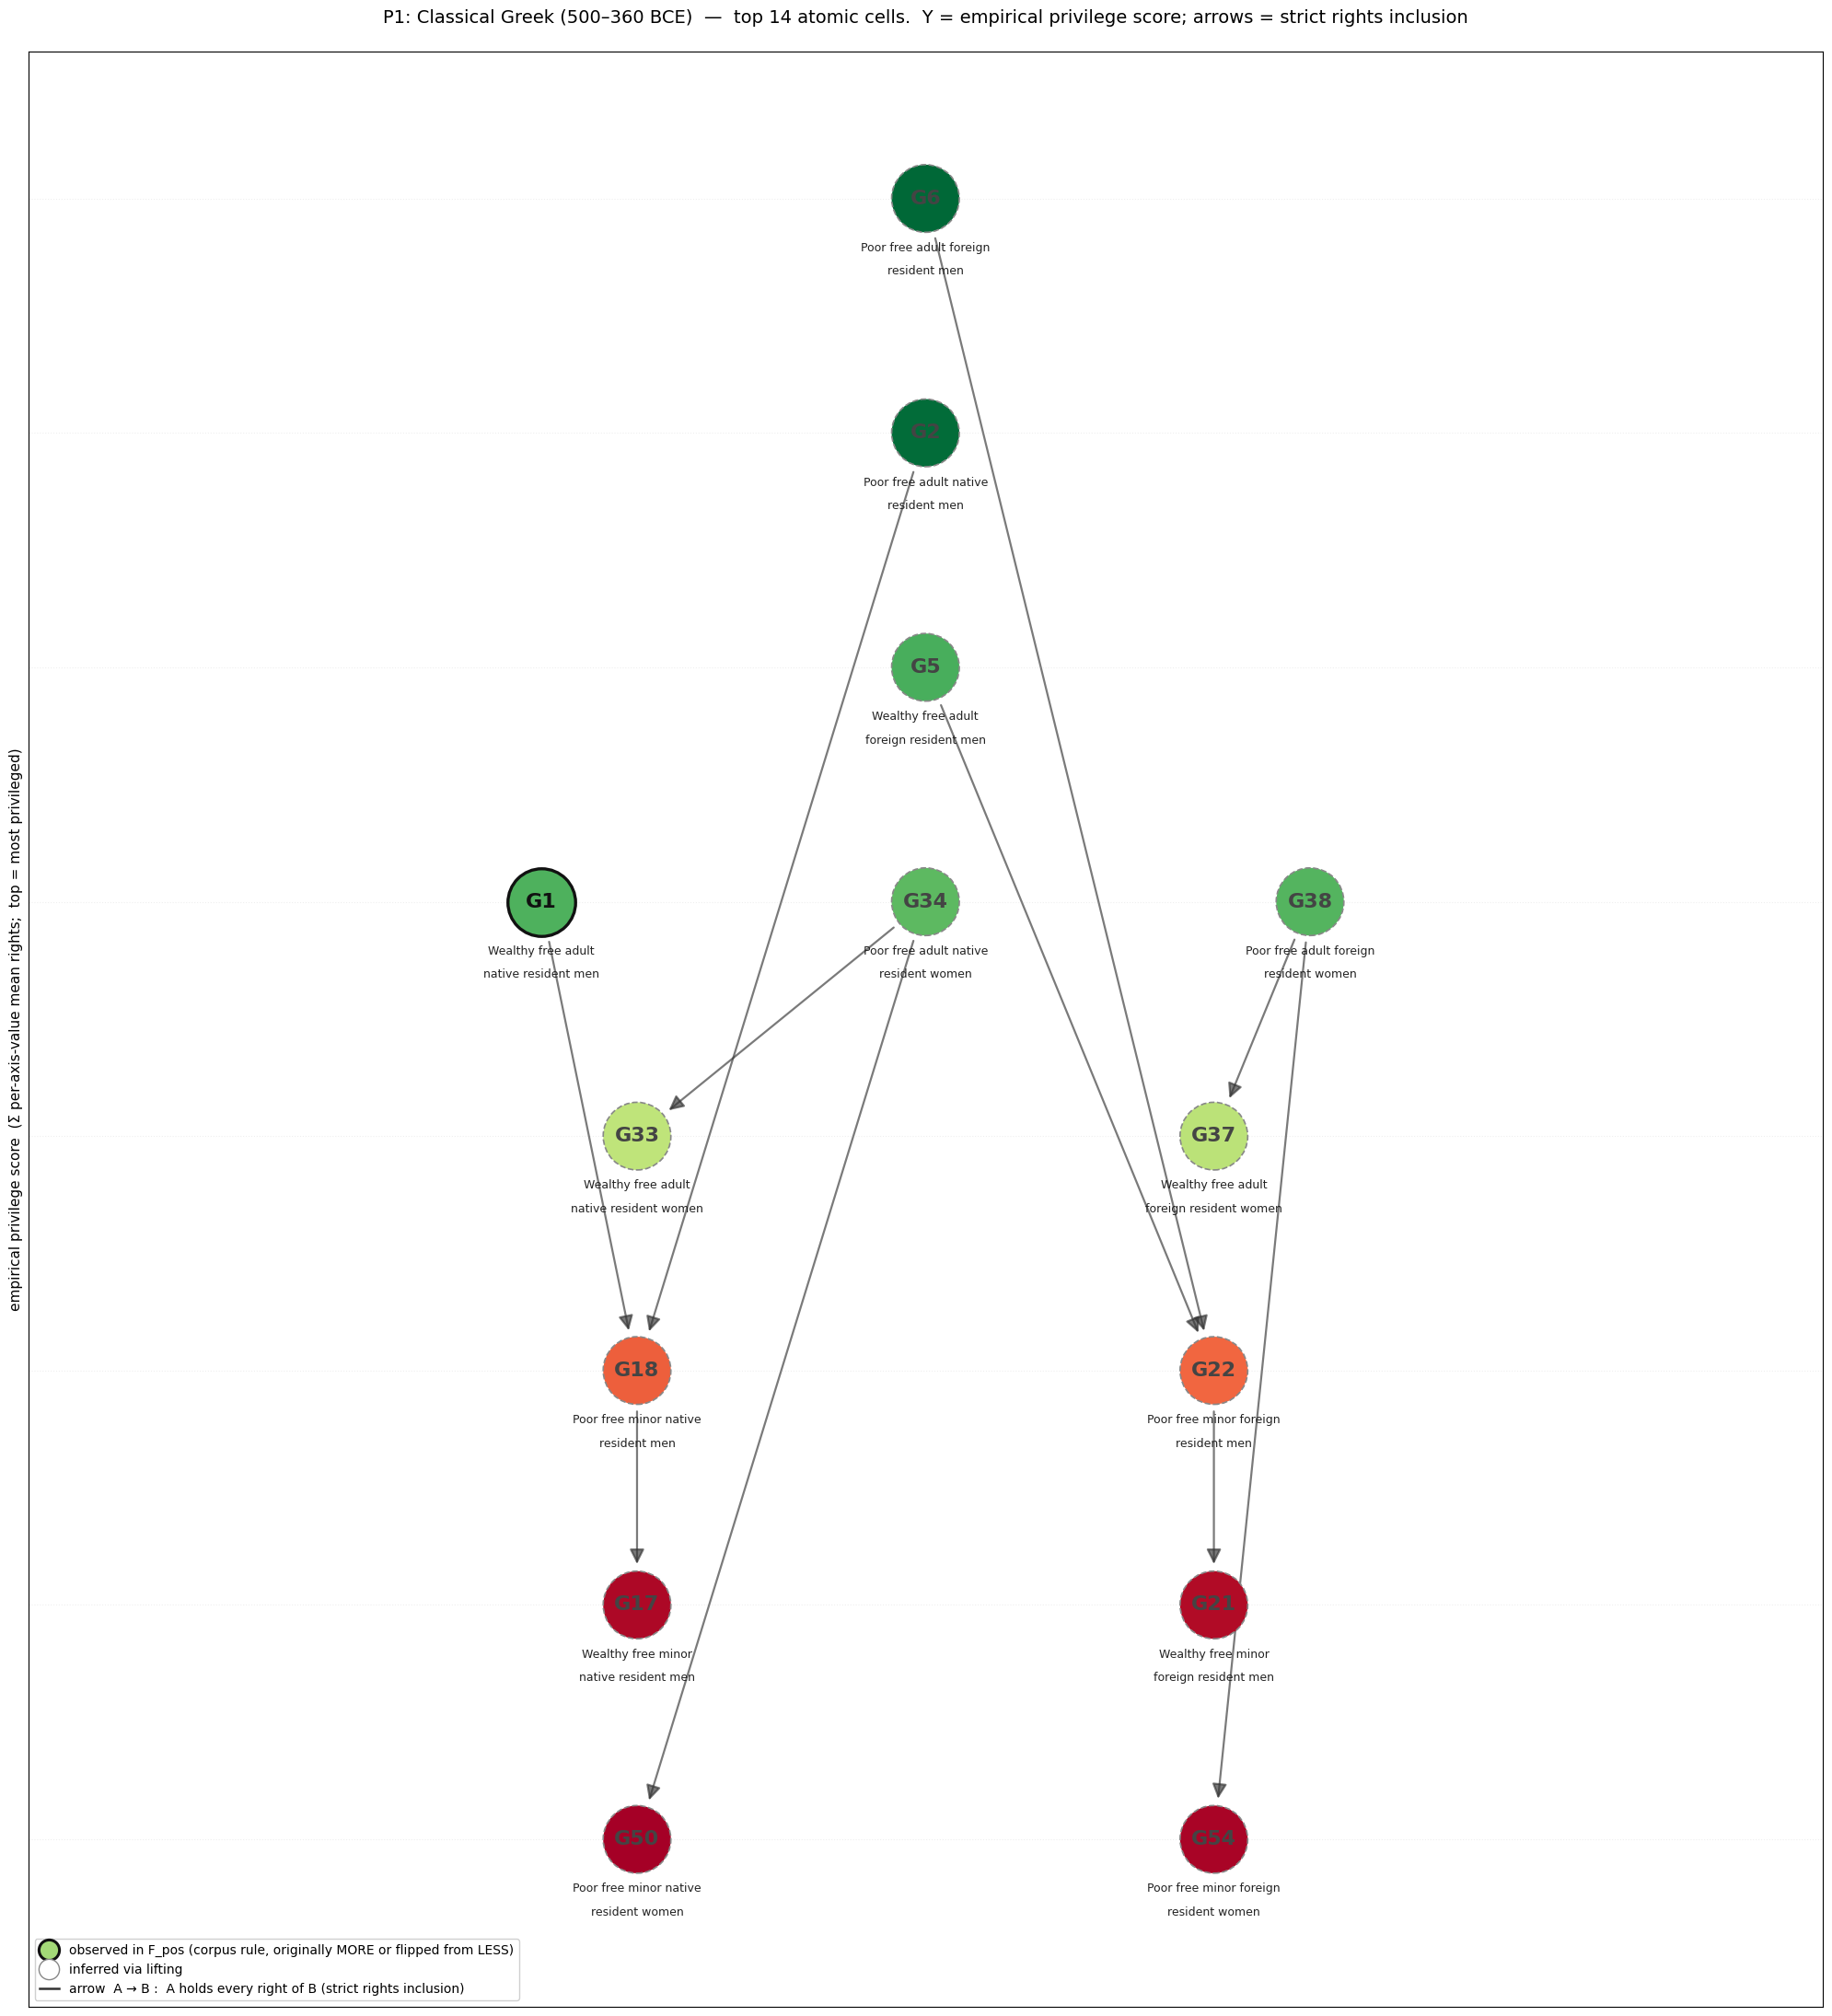

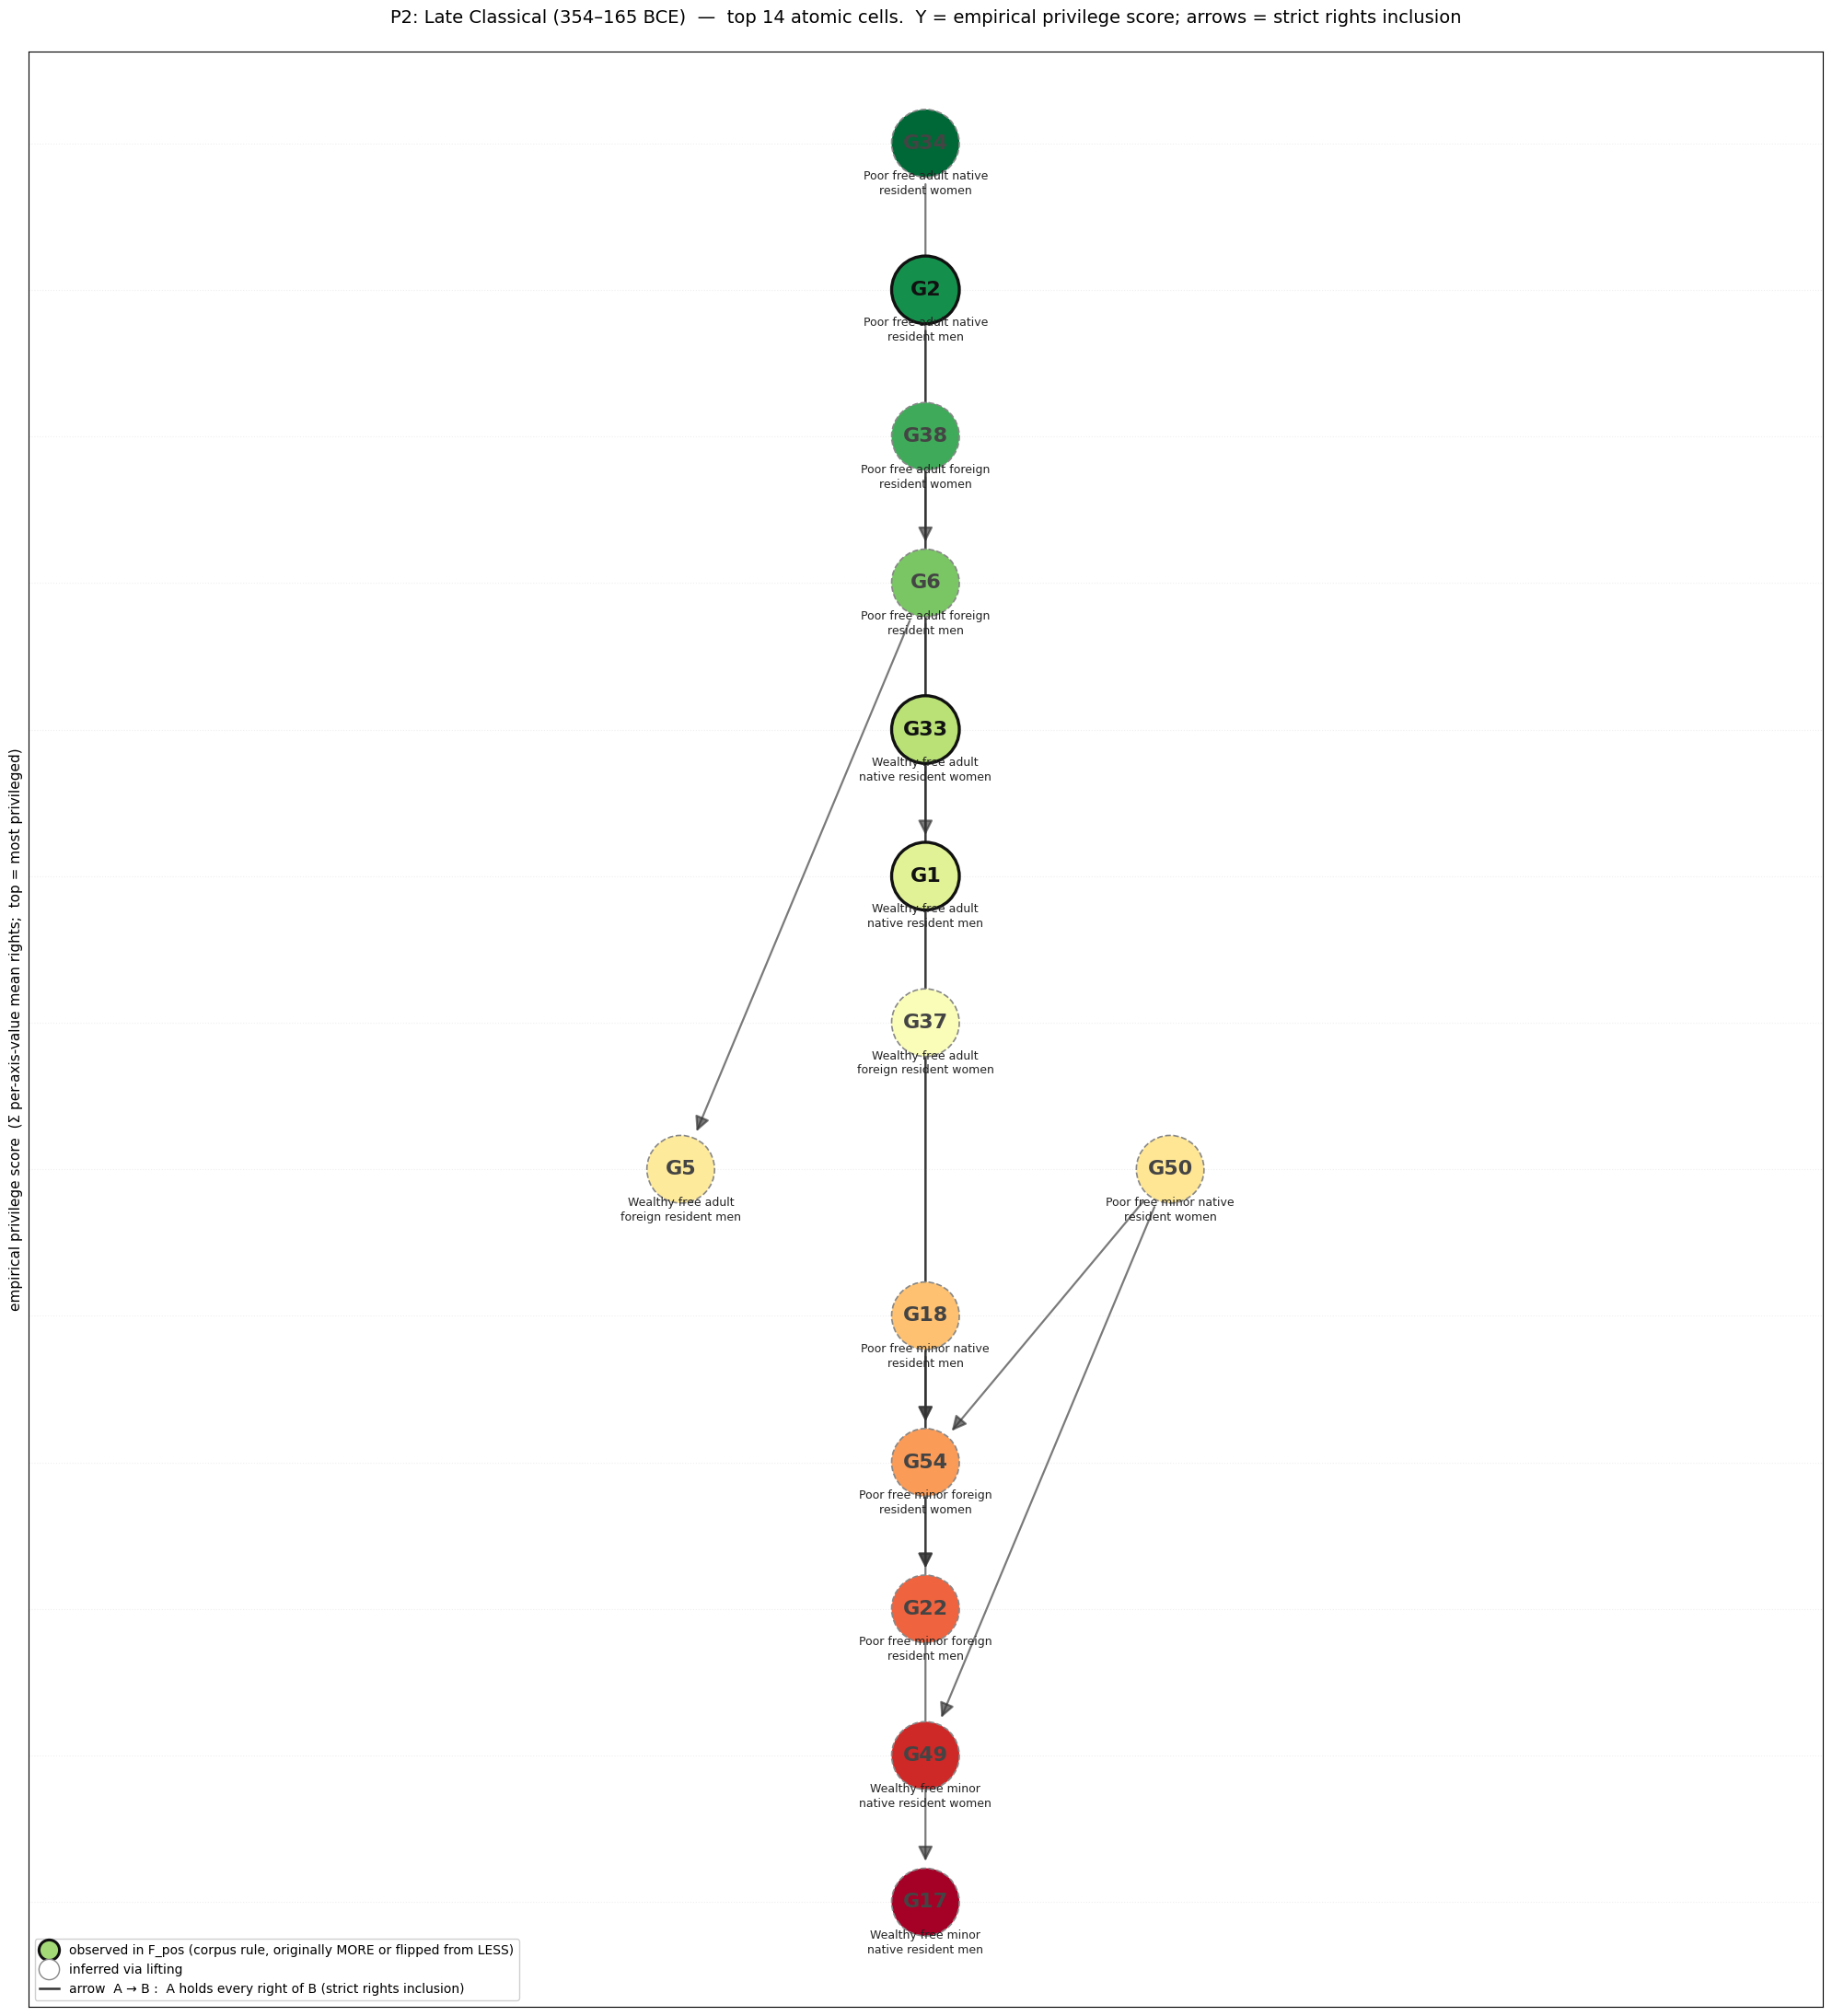

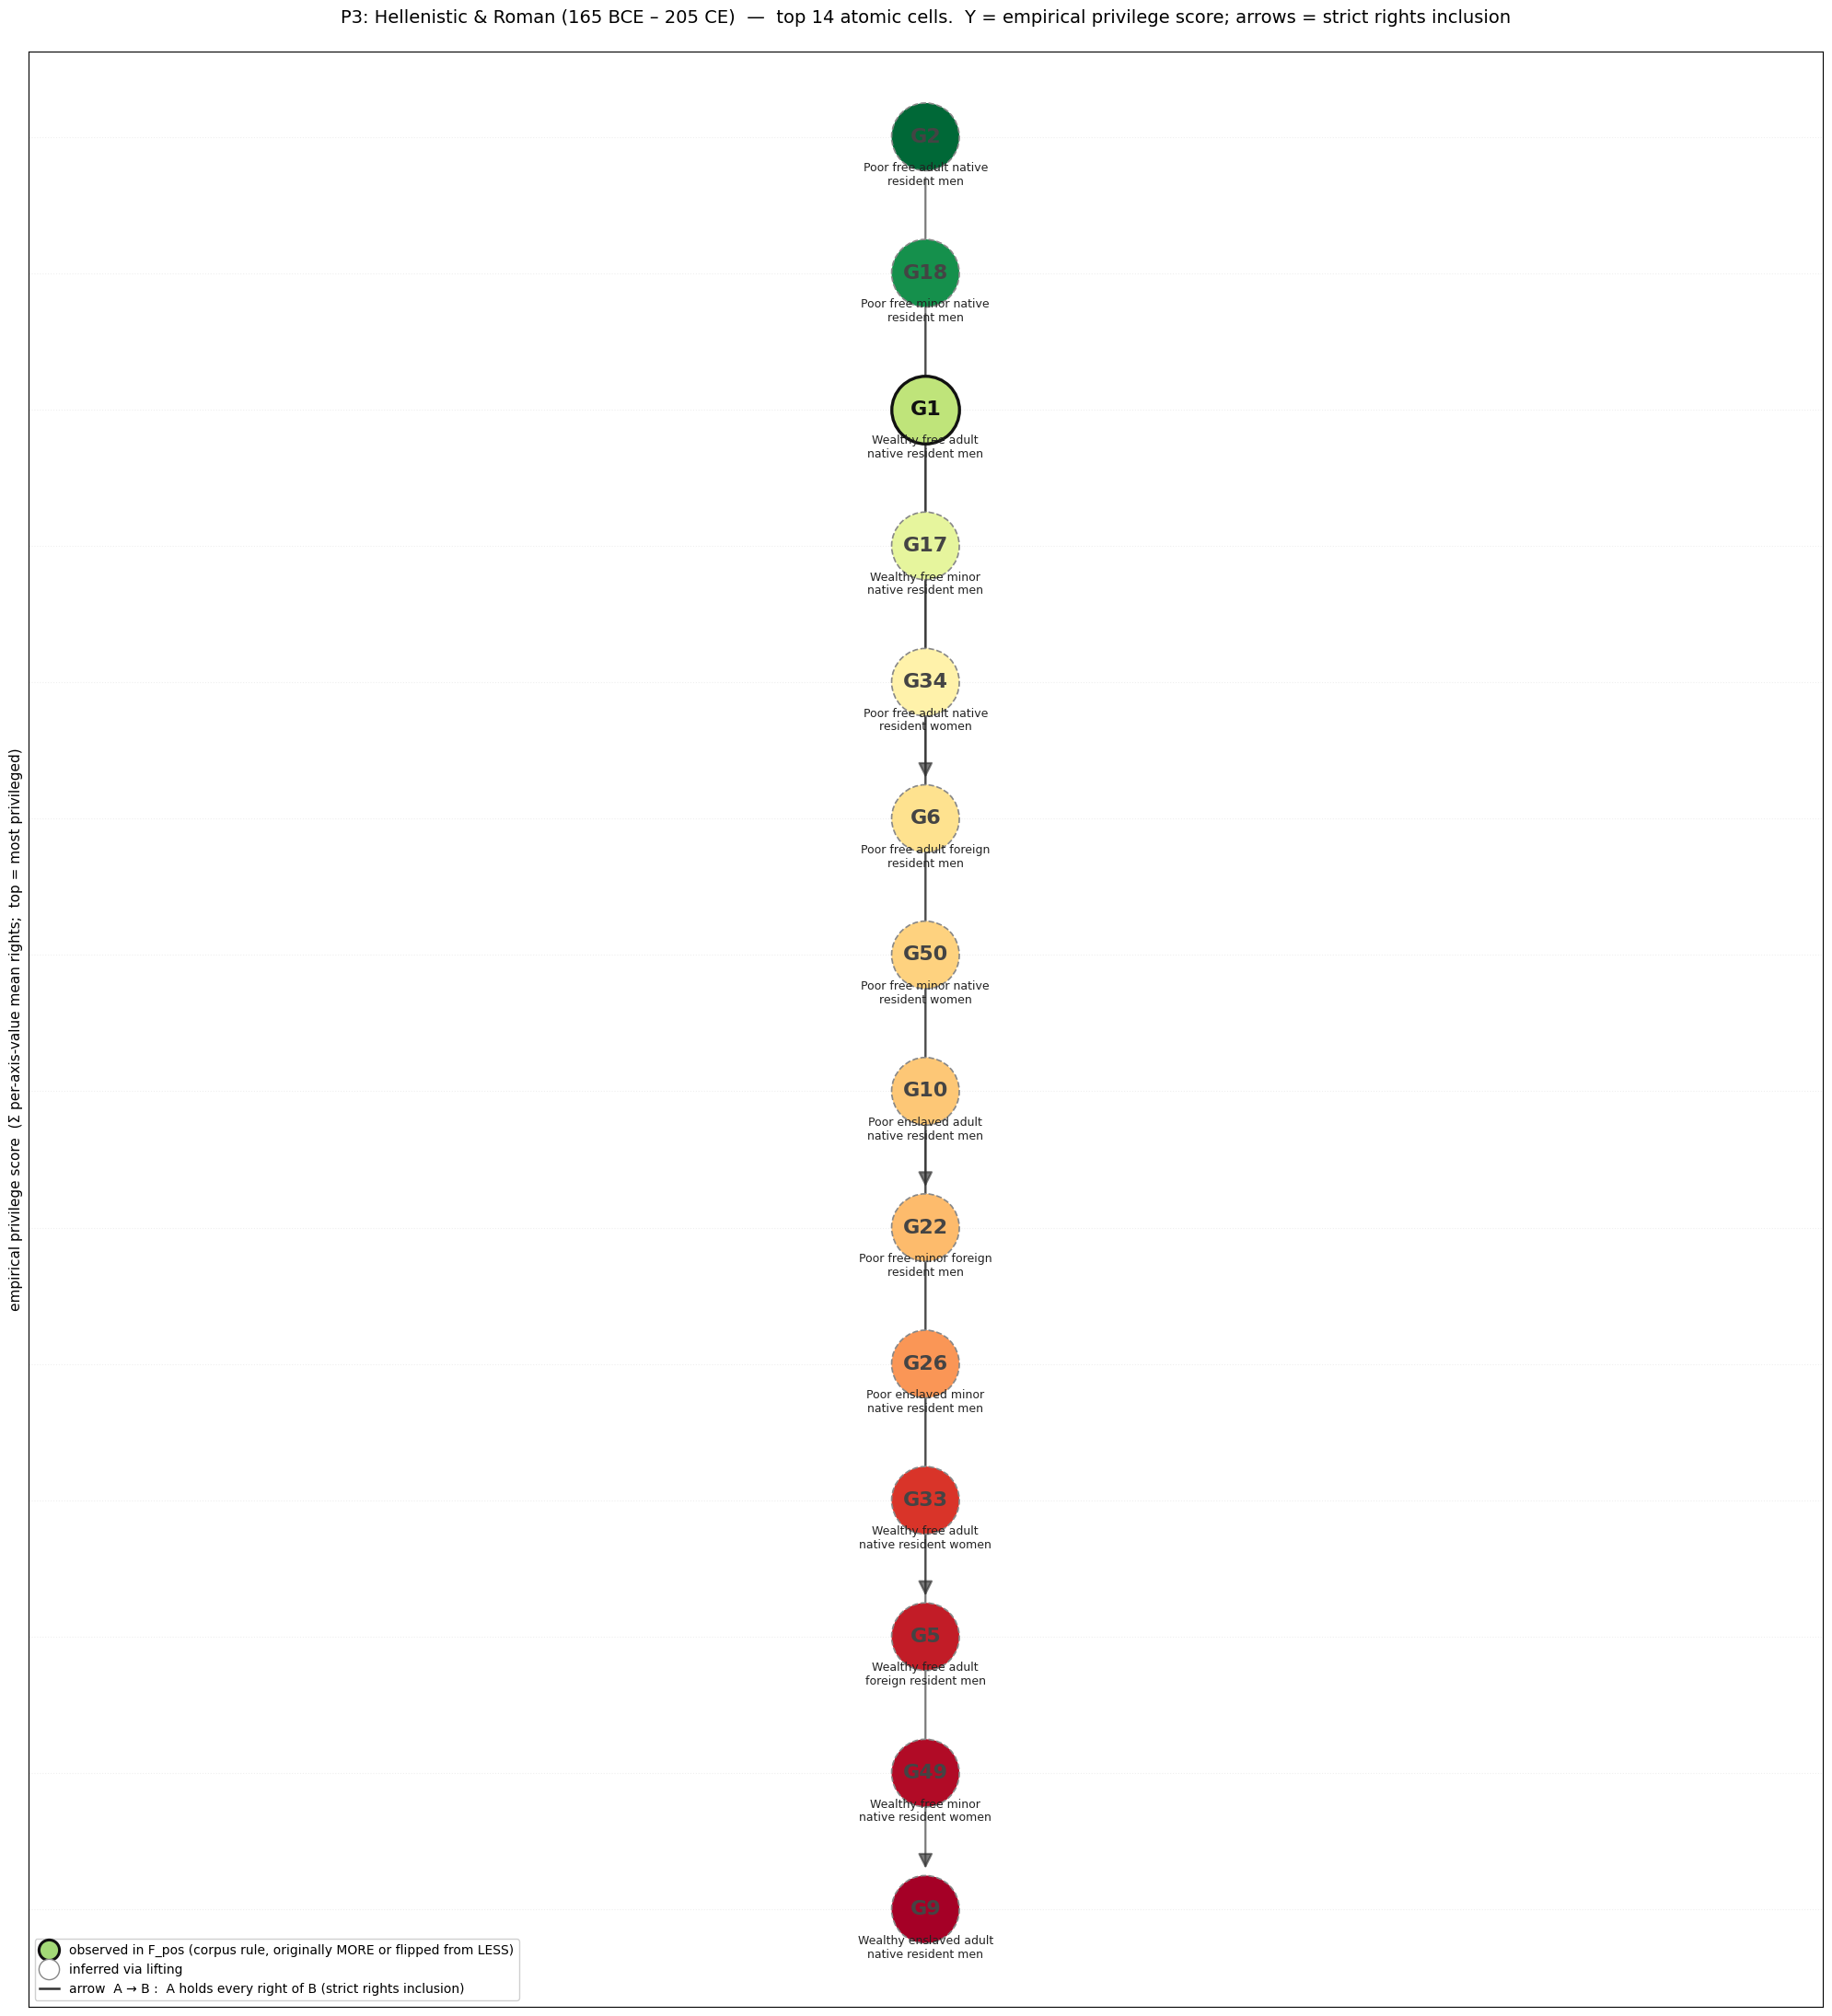

In [8]:
def is_observed_in_corpus(atomic_sig: str, period: str) -> bool:
    s = F_pos[F_pos['period3'] == period]
    return atomic_sig in set(s['cell_sig'].unique())

def build_rights_hasse(period: str, top_n: int):
    cells = ranks[period][:top_n]
    G = nx.DiGraph()
    for c in cells:
        G.add_node(c,
                   n_rights=len(lifted[period][c]),
                   score=scores[period][c],
                   label=labels[period][c],
                   gid=GLOBAL_NAME[c],
                   observed=is_observed_in_corpus(c, period))
    for a in cells:
        ra = lifted[period][a]
        for b in cells:
            if a == b: continue
            rb = lifted[period][b]
            if rb < ra:
                G.add_edge(a, b)
    H = nx.transitive_reduction(G)
    for n_, d in G.nodes(data=True):
        if n_ in H.nodes:
            H.nodes[n_].update(d)
    return H

def rights_layout(H, x_pad: float = 3.0):
    """Vertical position: empirical privilege score. Top of plot = most-privileged.
    Score bands are compressed onto a continuous axis but well-spaced visually."""
    score_to_cells = {}
    for c in H.nodes:
        # round to 1 decimal so very-close scores share a row
        key = round(H.nodes[c]['score'], 1)
        score_to_cells.setdefault(key, []).append(c)

    sorted_scores = sorted(score_to_cells.keys())
    # Stretch: use rank within sorted_scores × y_scale so consecutive bands are evenly spaced
    rank_of = {s: i for i, s in enumerate(sorted_scores)}
    y_scale = 3.5
    max_per_band = max(len(v) for v in score_to_cells.values())
    pos = {}
    for s, group in score_to_cells.items():
        group.sort(key=lambda c: int(H.nodes[c]['gid'][1:]))
        n = len(group)
        for i, c in enumerate(group):
            x = (i - (n - 1) / 2) * x_pad * (max_per_band / max(n, 1))
            y = rank_of[s] * y_scale
            pos[c] = (x, y)
    return pos, rank_of

def draw_one_period(period: str, top_n: int = 14):
    H = build_rights_hasse(period, top_n=top_n)
    pos, rank_of = rights_layout(H)

    fig, ax = plt.subplots(figsize=(20, 22))

    nx.draw_networkx_edges(
        H, pos, ax=ax,
        arrows=True, arrowstyle='-|>', arrowsize=24,
        width=1.6, alpha=0.65, edge_color='#333',
        connectionstyle='arc3,rad=0.0',
        min_target_margin=32, min_source_margin=32,
        node_size=2800,
    )

    obs_nodes = [n_ for n_ in H.nodes if H.nodes[n_]['observed']]
    inf_nodes = [n_ for n_ in H.nodes if not H.nodes[n_]['observed']]

    # Color the nodes by empirical privilege score so the ranking is visible at a glance
    score_vals = [H.nodes[n_]['score'] for n_ in H.nodes]
    vmin, vmax = min(score_vals), max(score_vals)

    if obs_nodes:
        nx.draw_networkx_nodes(
            H, pos, ax=ax, nodelist=obs_nodes,
            node_size=2800,
            node_color=[H.nodes[n_]['score'] for n_ in obs_nodes],
            cmap='RdYlGn', vmin=vmin, vmax=vmax,
            edgecolors='#111', linewidths=2.4,
        )
    if inf_nodes:
        art_inf = nx.draw_networkx_nodes(
            H, pos, ax=ax, nodelist=inf_nodes,
            node_size=2800,
            node_color=[H.nodes[n_]['score'] for n_ in inf_nodes],
            cmap='RdYlGn', vmin=vmin, vmax=vmax,
            edgecolors='#888', linewidths=1.2,
        )
        art_inf.set_linestyle('--')

    for n_ in H.nodes:
        x, y = pos[n_]
        ax.text(x, y, H.nodes[n_]['gid'],
                ha='center', va='center', fontsize=16, fontweight='bold',
                color='#111' if H.nodes[n_]['observed'] else '#444')
        label = H.nodes[n_]['label']
        words = label.split()
        wrapped, line = [], ''
        for w in words:
            if len(line) + len(w) + 1 > 24:
                wrapped.append(line); line = w
            else:
                line = (line + ' ' + w).strip()
        if line: wrapped.append(line)
        for k, ln in enumerate(wrapped):
            ax.text(x, y - 0.65 - 0.35 * k,
                    ln, ha='center', va='top', fontsize=9, color='#222')

    ax.set_title(period + '  —  top ' + str(top_n) +
                 ' atomic cells.  Y = empirical privilege score; arrows = strict rights inclusion',
                 fontsize=14, pad=22)
    ax.set_ylabel('empirical privilege score  (Σ per-axis-value mean rights;  top = most privileged)',
                  fontsize=11)
    sorted_scores = sorted(rank_of.keys())
    ax.set_yticks([rank_of[s] * 3.5 for s in sorted_scores])
    ax.set_yticklabels([f'{s:.1f}' for s in sorted_scores])
    ax.set_xticks([])
    xs = [x for x, _ in pos.values()]; ys = [y for _, y in pos.values()]
    ax.set_xlim(min(xs) - 4, max(xs) + 4)
    ax.set_ylim(min(ys) - 2.5, max(ys) + 2.2)

    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#a3d977',
               markeredgecolor='#111', markeredgewidth=2.2, markersize=16,
               label='observed in F_pos (corpus rule, originally MORE or flipped from LESS)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffffff',
               markeredgecolor='#888', markeredgewidth=1.0, markersize=16,
               label='inferred via lifting'),
        Line2D([0], [0], color='#333', lw=1.8,
               label='arrow  A → B :  A holds every right of B (strict rights inclusion)'),
    ]
    ax.legend(handles=legend_items, loc='lower left', fontsize=10,
              framealpha=0.92, handlelength=1.5)

    ax.set_facecolor('white')
    ax.grid(axis='y', alpha=0.20, linestyle=':')
    fig.tight_layout()
    plt.show()
    return H

for p in PERIODS:
    draw_one_period(p, top_n=14)

In [9]:
def legend_full(period: str) -> pd.DataFrame:
    rows = []
    for c in ATOMIC_CELLS:
        r = lifted[period][c]
        rows.append({
            'G':              GLOBAL_NAME[c],
            'observed':       'yes' if is_observed_in_corpus(c, period) else 'inferred',
            'name':           labels[period][c],
            'corpus_anchor':  corpus_g[period][c],
            'cell_sig':       c,
            'short':          cell_short(c),
            'n_rights':       len(r),
            'score':          round(scores[period][c], 1),
            'rights':         '; '.join(sorted(r)),
        })
    out = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
    return out

old_w = pd.get_option('display.max_colwidth')
pd.set_option('display.max_colwidth', 280)
for p in PERIODS:
    full = legend_full(p)
    n_obs = (full['observed'] == 'yes').sum()
    print('\n' + '=' * 100)
    print(p, f'— top 14 of 64 atomic cells   (observed in F_pos: {n_obs}/64)')
    print('=' * 100)
    display(full.head(14))
pd.set_option('display.max_colwidth', old_w)


P1: Classical Greek (500–360 BCE) — top 14 of 64 atomic cells   (observed in F_pos: 2/64)


,G,observed,name,corpus_anchor,cell_sig,short,n_rights,score,rights
0,G6,inferred,Poor free adult foreign resident men,Rhapsodes,Male/Adult/Free/Foreign/Resident/Low,M-A-F-F-R-L,20,83.5,Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from legal prosecution; Right ...
1,G2,inferred,Poor free adult native resident men,Rhapsodes,Male/Adult/Free/Native/Resident/Low,M-A-F-N-R-L,30,83.4,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Exemption from taxes; Political power; Protection from arbitrary banishment; Protection from capital punis...
2,G5,inferred,Wealthy free adult foreign resident men,The wealthy,Male/Adult/Free/Foreign/Resident/High,M-A-F-F-R-H,20,82.9,Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from legal prosecution; Right to a legal trial; Right to ...
3,G1,yes,Wealthy free adult native resident men,Wealthy citizens,Male/Adult/Free/Native/Resident/High,M-A-F-N-R-H,30,82.8,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Exemption from taxes; Political power; Protection from arbitrary banishment; Protection from capital punis...
4,G38,inferred,Poor free adult foreign resident women,Resident aliens,Female/Adult/Free/Foreign/Resident/Low,F-A-F-F-R-L,20,82.8,Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Political power; Protection from capital punishment; Protection from corporal punishment; Right to a dowry; Right to a legal trial;...
5,G34,inferred,Poor free adult native resident women,Minors,Female/Adult/Free/Native/Resident/Low,F-A-F-N-R-L,22,82.8,Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from military service; Exemption from taxes; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from ens...
6,G37,inferred,Wealthy free adult foreign resident women,The wealthy,Female/Adult/Free/Foreign/Resident/High,F-A-F-F-R-H,19,82.2,Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from military service; Political power; Protection from capital punishment; Protection from corporal punishment; Right to a dowry; Right to a legal trial; Right to address the assembl...
7,G33,inferred,Wealthy free adult native resident women,The wealthy,Female/Adult/Free/Native/Resident/High,F-A-F-N-R-H,21,82.2,Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from military service; Exemption from taxes; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from enslavement; Right to a dowry; R...
8,G18,inferred,Poor free minor native resident men,Boys,Male/Minor/Free/Native/Resident/Low,M-M-F-N-R-L,19,80.5,Access to public honors; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from enslavement; Protection from legal prosecution; Right to a l...
9,G22,inferred,Poor free minor foreign resident men,Slaves,Male/Minor/Free/Foreign/Resident/Low,M-M-F-F-R-L,16,80.5,Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Political power; Protection from capital punishment; Protection from corporal punishment; Protection from legal pros


P2: Late Classical (354–165 BCE) — top 14 of 64 atomic cells   (observed in F_pos: 3/64)


,G,observed,name,corpus_anchor,cell_sig,short,n_rights,score,rights
0,G34,inferred,Poor free adult native resident women,The poor,Female/Adult/Free/Native/Resident/Low,F-A-F-N-R-L,27,79.0,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor; Exemption from public service financing; Exemption from taxes; Political power; Protection from...
1,G2,yes,Poor free adult native resident men,The infirm poor,Male/Adult/Free/Native/Resident/Low,M-A-F-N-R-L,34,78.5,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from legal audit; Exemption from manual labor; Exemption from public service financing; Exemption from taxes; Poli...
2,G38,inferred,Poor free adult foreign resident women,Metics,Female/Adult/Free/Foreign/Resident/Low,F-A-F-F-R-L,25,78.0,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor; Exemption from public service financing; Exemption from taxes; Political power; Protection from...
3,G6,inferred,Poor free adult foreign resident men,Metics,Male/Adult/Free/Foreign/Resident/Low,M-A-F-F-R-L,27,77.5,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from legal audit; Exemption from manual labor; Exemption from public service financing; Exemption from taxes; Poli...
4,G33,yes,Wealthy free adult native resident women,Noble women,Female/Adult/Free/Native/Resident/High,F-A-F-N-R-H,23,76.8,Access to public honors; Access to religious rites; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor; Exemption from taxes; Political power; Protection from capital punishment; Protection from corporal punishment; Protecti...
5,G1,yes,Wealthy free adult native resident men,Citizens,Male/Adult/Free/Native/Resident/High,M-A-F-N-R-H,32,76.2,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from legal audit; Exemption from manual labor; Exemption from taxes; Political power; Protection from arbitrary ba...
6,G37,inferred,Wealthy free adult foreign resident women,Rich women,Female/Adult/Free/Foreign/Resident/High,F-A-F-F-R-H,21,75.8,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor; Exemption from taxes; Political power; Protection from capital punishment; Protection from ensl...
7,G5,inferred,Wealthy free adult foreign resident men,The wealthy,Male/Adult/Free/Foreign/Resident/High,M-A-F-F-R-H,20,75.2,Access to public honors; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from legal audit; Exemption from manual labor; Exemption from taxes; Political power; Protection from capital punishment; Protection from ens...
8,G50,inferred,Poor free minor native resident women,Orphans of fallen soldiers,Female/Minor/Free/Native/Resident/Low,F-M-F-N-R-L,26,75.2,Access to public honors; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor; Exemption from public service financing; Exemption from taxes; Political power; Protection from corporal punishment; Prote...
9,G18,inferred,Poor free minor native resident men,Orphans of fallen soldiers,Male/Minor/Free/Native/Resident/Low,M-M-F-N-R-L,28,74.6,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from manual labor;


P3: Hellenistic & Roman (165 BCE – 205 CE) — top 14 of 64 atomic cells   (observed in F_pos: 1/64)


,G,observed,name,corpus_anchor,cell_sig,short,n_rights,score,rights
0,G2,inferred,Poor free adult native resident men,The multitude,Male/Adult/Free/Native/Resident/Low,M-A-F-N-R-L,28,107.8,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection from legal prosecution;...
1,G18,inferred,Poor free minor native resident men,Slaves,Male/Minor/Free/Native/Resident/Low,M-M-F-N-R-L,27,107.4,Access to education; Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection fr...
2,G1,yes,Wealthy free adult native resident men,Nobles,Male/Adult/Free/Native/Resident/High,M-A-F-N-R-H,28,106.0,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection from public libel; Righ...
3,G17,inferred,Wealthy free minor native resident men,Eurypontidae,Male/Minor/Free/Native/Resident/High,M-M-F-N-R-H,27,105.6,Access to education; Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from manual labor; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection fr...
4,G34,inferred,Poor free adult native resident women,The multitude,Female/Adult/Free/Native/Resident/Low,F-A-F-N-R-L,27,105.0,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection from legal prosecution; Protection from public libel...
5,G6,inferred,Poor free adult foreign resident men,Liberated Greek allies,Male/Adult/Free/Foreign/Resident/Low,M-A-F-F-R-L,22,104.8,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Political power; Protection from corporal punishment; Protection from enslavement; Protection from legal prosecution; Protection from public libel; Right to a legal tri...
6,G50,inferred,Poor free minor native resident women,Slaves,Female/Minor/Free/Native/Resident/Low,F-M-F-N-R-L,26,104.6,Access to education; Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection from public libel; Right to a d...
7,G10,inferred,Poor enslaved adult native resident men,Helots,Male/Adult/Enslaved/Native/Resident/Low,M-A-E-N-R-L,21,104.4,Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Exemption from compulsory public financing; Exemption from taxes; Political power; Protection from corporal punishment; Protection from enslavement; Protection from leg...
8,G22,inferred,Poor free minor foreign resident men,Slaves,Male/Minor/Free/Foreign/Resident/Low,M-M-F-F-R-L,19,104.3,Access to education; Access to public honors; Access to religious rites; Access to the gymnasium; Eligibility for public office; Political power; Protection from corporal punishment; Protection from enslavement; Protection from public libel; Right to bodily autonomy; Right to...
9,G26,inferred,Poor enslaved minor native resident men,Helots,Male/Minor/Enslaved/Native/Resident/Low,M-M-E-N-R-L,20,104.0,Access to education; Access to religious rites; Access to the gymnasium; Exemption from compulsory public financing; Exemption from taxes; Political power; Protection from corporal punishment; Prote

## 5. What does `*` mean — the *lifting* interpretation of unspecified axes

A practical question your data raises. When the criterion vector for a rule has `*` on an axis (e.g. `Male/Adult/Free/Native/Resident/*` — wealth unspecified), what does that *mean* for who actually holds the right?

### Two readings

1. **Lifting ("applies to everyone in the cell").** The rule applies regardless of the unspecified axis: anyone who satisfies the *pinned* criteria gets the right. A vote-rule on `Male/Adult/Free/Native/Resident/*` is a vote-rule for every adult free native male resident, *whatever their wealth*. Equivalently: if cell $A$ ⪯ cell $B$ in the partial order (A is a refinement of B), then $\rho(A) \supseteq \rho(B)$ — rights at coarser cells *propagate down* to all their refinements. This is the semantics the Hasse diagram in §4 already assumes (it's why a node lower in the diagram "inherits" the rights of its ancestors).

2. **Don't-know ("the text simply doesn't say").** The rule mentions the pinned criteria explicitly; we have no evidence about whether wealth (or any other unspecified axis) was relevant. We can't conclude the right covers all wealth levels — only that the corpus is silent.

### Which one should we use?

For the partial order as a *positive* rights map, the lifting reading is the right default. It is also the reading that lets the partial order do empirical work — without it, every cell is an island and there is no inheritance to draw. So:

> When wealth (or any other axis) is `*`, we read the rule as: *any person who fits the cell's pinned criteria, regardless of their value on the unspecified axis, holds this right.* The right is **lifted** to the cell and propagates downward through every refinement of it.

A consequence: rights at the universal cell `*/*/*/*/*/*` are held by *everybody* — the human-rights ceiling. Rights at `Male/Adult/Free/Native/Resident/*` are held by all wealth-levels of that cell, including `…/High` and `…/Low` even when no specific rule places those resources at the more specific cells.

### Where lifting must be qualified

The lifting interpretation can be overridden by a *more specific* rule that explicitly *contradicts* it ("specificity wins"). For example, if `Male/Adult/Free/Native/Resident/*` holds the right to vote, but a more specific cell `Male/Adult/Free/Native/Resident/Low` (poor Athenian male citizens) has a LESS rule saying *the very poor cannot vote*, then we should subtract that right at the refinement. We do not currently model that override — we're working with MORE-only evidence. Specificity-wins becomes important when we re-introduce LESS rules in a future iteration.

### Stronger version — "explicit" vs "inherited" rights

A useful refinement of the Hasse diagram is to distinguish, at each cell, the rights it holds **explicitly** (some rule directly puts the resource at this cell) from the rights it holds **by inheritance** (a less-specific ancestor cell holds the resource, so by lifting the refinement holds it too). The node colour in §4 currently counts only the explicit rights; the inherited count is computable by walking the partial order upward. Let me know if you want that view — it's a small addition and makes the difference between *new* rights at a cell vs *inherited* ones legible.